Mean Overall RMSE: 1.357


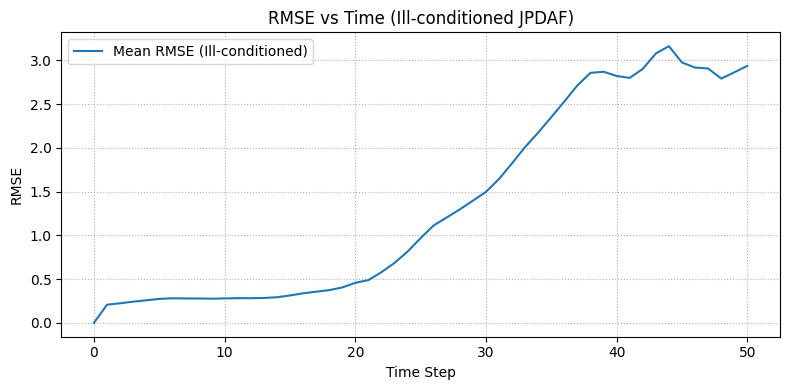

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from ordered_set import OrderedSet

from StoneSoupID.stonesoupID.types.groundtruth import GroundTruthPath, GroundTruthState
from StoneSoupID.stonesoupID.models.transition.linear import (
    CombinedLinearGaussianTransitionModel,
    ConstantVelocity,
    LinearGaussianTimeInvariantTransitionModel
)
from StoneSoupID.stonesoupID.models.measurement.linear import LinearGaussian
from StoneSoupID.stonesoupID.types.detection import TrueDetection
from StoneSoupID.stonesoupID.types.state import GaussianState
from StoneSoupID.stonesoupID.predictor.kalman import KalmanPredictor
from StoneSoupID.stonesoupID.updater.kalman import KalmanUpdater
from StoneSoupID.stonesoupID.hypothesiser.probability import PDAHypothesiser
from StoneSoupID.stonesoupID.dataassociator.probability import JPDAwithLBP as JPDA
from StoneSoupID.stonesoupID.initiator.simple import MultiMeasurementInitiator
from StoneSoupID.stonesoupID.deleter.time import UpdateTimeDeleter
from StoneSoupID.stonesoupID.tracker.simple import MultiTargetTracker


# ---- Augmented Measurement Model for AR(1) Noise ----
class Augmented2DMeasurement(LinearGaussian):
    def function(self, state_vector, noise=False, **kwargs):
        # Accept both State objects and numpy arrays
        if hasattr(state_vector, 'state_vector'):
            s = np.asarray(state_vector.state_vector).flatten()
        else:
            s = np.asarray(state_vector).flatten()
        vec = np.array([
            s[0] + s[4],
            s[2] + s[5]
        ]).reshape(2, 1)
        if noise is True:
            vec += self.rvs()
        return vec

    def jacobian(self, state_vector, **kwargs):
        H = np.zeros((2, 6))
        H[0, 0] = 1  # x
        H[0, 4] = 1  # n_x
        H[1, 2] = 1  # y
        H[1, 5] = 1  # n_y
        return H

num_seeds = 1
num_steps = 50
rho = 0
process_noise_var = 0.005
sigma = 5.0  

# Ill-conditioned settings:
init_states = [
    [0, 1, 0, 1, 0, 0],
    [0.2, 1, 0.2, 1, 0, 0]  # Extremely close to target 1!
]

# Large measurement noise covariance
large_noise_covar = np.eye(2) * 100.0

# Patch the measurement model in run_kf_experiment dynamically
def run_kf_experiment_ill(seed, num_steps, rho, process_noise_var, sigma):
    # (Copy your original run_kf_experiment here, but with these lines modified:)
    np.random.seed(seed)
    # --- Use local ill-conditioned init_states ---
    ar1_model = LinearGaussianTimeInvariantTransitionModel(
        transition_matrix=np.array([[rho]]),
        covariance_matrix=np.array([[sigma**2]])
    )
    transition_model = CombinedLinearGaussianTransitionModel([
        ConstantVelocity(np.sqrt(process_noise_var)),
        ConstantVelocity(np.sqrt(process_noise_var)),
        ar1_model, ar1_model
    ])
    measurement_model = Augmented2DMeasurement(
        ndim_state=6,
        mapping=(0, 2),
        noise_covar=large_noise_covar  # Ill-conditioned!
    )
    dt = 0.1
    from datetime import datetime, timedelta
    timesteps = [datetime.now() + timedelta(seconds=k*dt) for k in range(num_steps + 1)]
    from ordered_set import OrderedSet
    truths = OrderedSet()
    truth_paths = []
    for state in init_states:
        truth = GroundTruthPath([GroundTruthState(state, timestamp=timesteps[0])])
        for k in range(1, num_steps + 1):
            next_state = transition_model.function(truth[k-1], noise=True, time_interval=timedelta(seconds=dt))
            truth.append(GroundTruthState(next_state, timestamp=timesteps[k]))
        truths.add(truth)
        truth_paths.append(truth)
    all_measurements = []
    for k in range(num_steps + 1):
        measurement_set = set()
        for idx, truth in enumerate(truth_paths):
            s = truth[k].state_vector.flatten()
            meas_vec = np.array([s[0] + s[4], s[2] + s[5]])
            measurement_set.add(TrueDetection(
                state_vector=meas_vec.reshape(-1, 1),
                groundtruth_path=truth,
                timestamp=timesteps[k],
                measurement_model=measurement_model
            ))
        all_measurements.append(measurement_set)

    predictor = KalmanPredictor(transition_model)
    updater = KalmanUpdater(measurement_model)
    hypothesiser = PDAHypothesiser(
        predictor=predictor,
        updater=updater,
        clutter_spatial_density=1e-12,
        prob_detect=1.0,
        prob_gate=0.999
    )
    data_associator = JPDA(hypothesiser=hypothesiser)
    prior_cov = np.diag([100, 10, 100, 10, 25, 25])
    prior_state = GaussianState(np.array(init_states[0]).reshape(-1, 1), prior_cov, timestamp=timesteps[0])
    deleter = UpdateTimeDeleter(time_since_update=timedelta(seconds=10))
    initiator = MultiMeasurementInitiator(
        prior_state=prior_state,
        deleter=deleter,
        data_associator=data_associator,
        updater=updater,
        measurement_model=measurement_model,
        min_points=1
    )

    detector = iter(list(zip(timesteps, all_measurements)))
    tracker = MultiTargetTracker(
        initiator=initiator,
        deleter=deleter,
        data_associator=data_associator,
        updater=updater,
        detector=detector
    )

    tracks = set()
    for time, curr_tracks in tracker:
        tracks |= curr_tracks
    tracks = {track for track in tracks if len(track) > 3}
    tracks = list(tracks)

    truth_arrays = [np.array([[s.state_vector[0], s.state_vector[2]] for s in truth]) for truth in truth_paths]
    track_arrays = [np.array([[s.state_vector[0], s.state_vector[2]] for s in track]) for track in tracks]

    rmse_time = []
    for t in range(num_steps + 1):
        errors = []
        for truth in truth_arrays:
            min_err = None
            for track in track_arrays:
                if t < track.shape[0]:
                    err = np.linalg.norm(track[t] - truth[t])
                    if (min_err is None) or (err < min_err):
                        min_err = err
            if min_err is not None:
                errors.append(min_err ** 2)
        if errors:
            rmse_t = np.sqrt(np.mean(errors))
            rmse_time.append(rmse_t)
        else:
            rmse_time.append(np.nan)
    overall_rmse = np.nanmean(rmse_time)
    return np.array(rmse_time), overall_rmse

# Now, run over seeds, count failures, plot results
fail_count = 0
overall_rmse_list = []
all_rmse = []

seeds = np.random.randint(0, 1e9, num_seeds)
for seed in range(num_seeds):
    rmse_time, overall_rmse = run_kf_experiment_ill(seed, num_steps, rho, process_noise_var, sigma)
    overall_rmse_list.append(overall_rmse)
    all_rmse.append(rmse_time)

if overall_rmse_list:
    print(f"Mean Overall RMSE: {np.mean(overall_rmse_list):.3f}")

    all_rmse = np.vstack(all_rmse)
    mean_rmse = np.nanmean(all_rmse, axis=0)

    plt.figure(figsize=(8, 4))
    plt.plot(mean_rmse, label="Mean RMSE (Ill-conditioned)")
    plt.xlabel("Time Step")
    plt.ylabel("RMSE")
    plt.title("RMSE vs Time (Ill-conditioned JPDAF)")
    plt.grid(linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("All runs failed due to numerical instability!")



In [ ]:
# Ill-conditioned JPDAF example